# 02 — Обзор выбросов и аномальных строк

Этот notebook отдельно от основного EDA отмечает статистические кандидаты по IQR и robust Z-score (MAD). Он **не изменяет, не удаляет и не исправляет данные**.

In [1]:
from pathlib import Path
import importlib
import sys

from IPython.display import display
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
    if (candidate / "README.md").exists() and (candidate / "src").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml_project import (
    DataCatalog,
    MarkdownDocument,
    analyze_numeric_anomalies,
    plot_anomaly_summary,
    plot_feature_anomalies,
    validate_feature_groups,
)
from ml_project.docsync import dataframe_to_markdown
import ml_project.config as project_config

IQR_MULTIPLIER = 1.5
ROBUST_Z_THRESHOLD = 3.5
TOP_ROWS = 30

print(f"Корень проекта: {PROJECT_ROOT}")

Корень проекта: D:\Projects\Titanik-ML-project


## 1. Загрузить те же EDA-данные

Границы всегда рассчитываются только по train и без изменений применяются к inference/test.

In [2]:
project_config = importlib.reload(project_config)
catalog = DataCatalog(
    PROJECT_ROOT,
    project_config.RAW_DIR,
    project_config.DATASETS,
)
catalog.validate()
datasets = catalog.load_all()

EDA_ROLES = {"train", "inference"}
eda_datasets = {
    name: frame
    for name, frame in datasets.items()
    if project_config.DATASETS[name].get("role") in EDA_ROLES
}
train = eda_datasets[project_config.TRAIN_DATASET]
feature_groups = validate_feature_groups(
    train,
    project_config.FEATURE_GROUPS,
    target=project_config.TARGET,
)
numeric_features = [
    *feature_groups["numeric"],
    *feature_groups["count"],
]
print("Датасеты:", ", ".join(eda_datasets))
print("Числовые + счётные:", ", ".join(numeric_features) or "—")

Датасеты: train, test
Числовые + счётные: Age, Fare, SibSp, Parch


## 2. Рассчитать обзор

IQR и MAD — сигналы для просмотра, а не правило удаления строки. Если IQR или MAD равен нулю, соответствующий метод для признака честно отключается.

,feature,reference_non_missing,reference_min,q1,median,q3,reference_max,iqr,lower_bound,upper_bound,mad,iqr_available,mad_available
0,Age,714,0.42,20.1250,28.0000,38.0,80.0000,17.8750,-6.6875,64.8125,9.0000,True,True
1,Fare,891,0.00,7.9104,14.4542,31.0,512.3292,23.0896,-26.7240,65.6344,6.9042,True,True
2,SibSp,891,0.00,0.0000,0.0000,1.0,8.0000,1.0000,-1.5000,2.5000,0.0000,True,False
3,Parch,891,0.00,0.0000,0.0000,0.0,6.0000,0.0000,NaN,NaN,0.0000,False,False


,dataset,feature,non_missing,iqr_outliers,mad_outliers,any_outliers,outlier_share,outside_reference_range
0,train,Age,714,11,1,11,1.54%,0
1,train,Fare,891,116,160,160,17.96%,0
2,train,SibSp,891,46,0,46,5.16%,0
3,train,Parch,891,0,0,0,0.00%,0
4,test,Age,332,2,1,2,0.60%,2
5,test,Fare,417,55,80,80,19.18%,0
6,test,SibSp,418,11,0,11,2.63%,0
7,test,Parch,418,0,0,0,0.00%,2


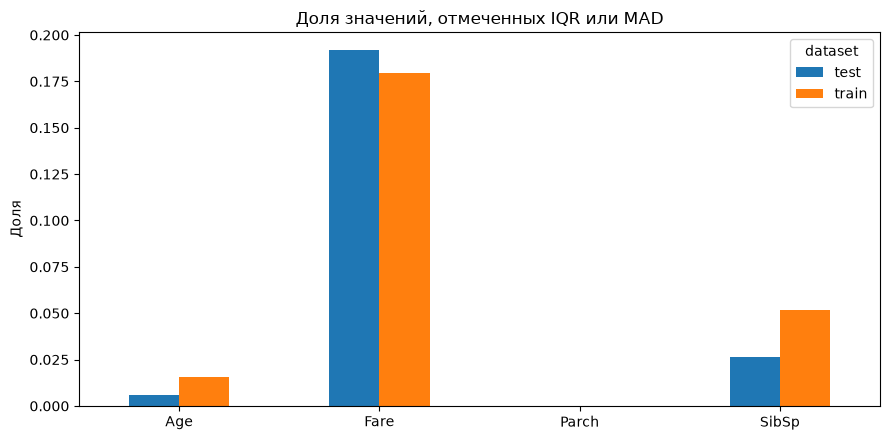

In [3]:
anomaly_report = analyze_numeric_anomalies(
    eda_datasets,
    reference_dataset=project_config.TRAIN_DATASET,
    columns=numeric_features,
    iqr_multiplier=IQR_MULTIPLIER,
    robust_z_threshold=ROBUST_Z_THRESHOLD,
)

display(anomaly_report.feature_bounds.round(4))
display(
    anomaly_report.dataset_summary.style.format(
        {"outlier_share": "{:.2%}"}
    )
)
axis = plot_anomaly_summary(anomaly_report)
axis.figure.tight_layout()
plt.show()

## 3. Посмотреть отмеченные значения

Показываются только признаки, где хотя бы один датасет получил IQR/MAD-флаг. Красный крест — отмеченное значение, пунктир — границы train-IQR.

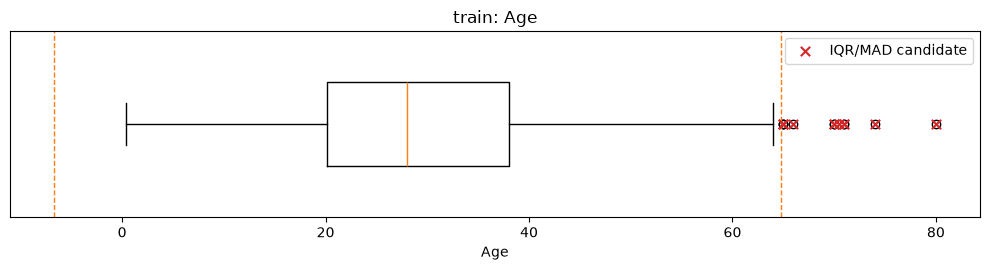

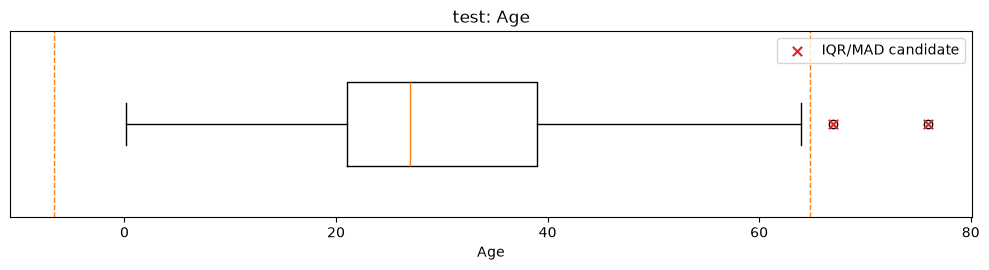

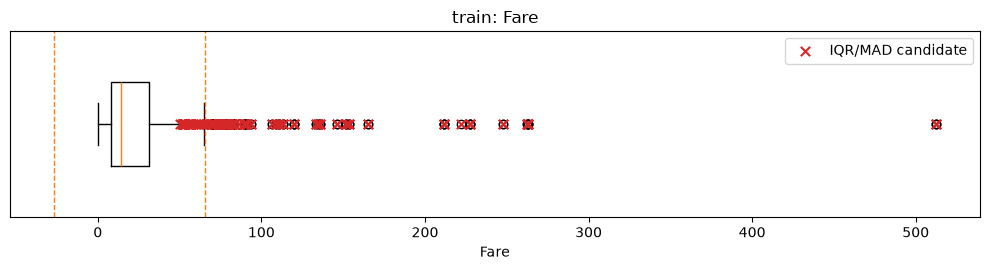

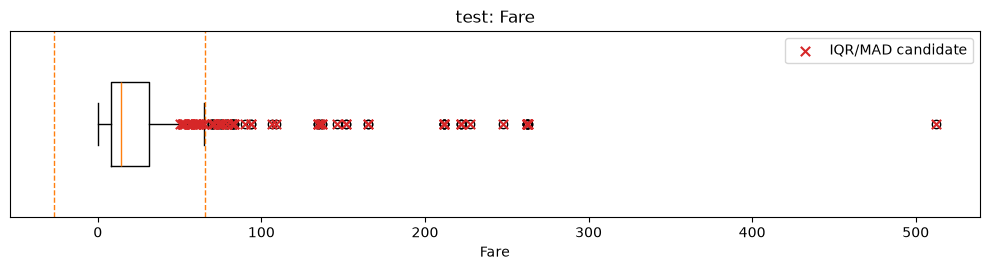

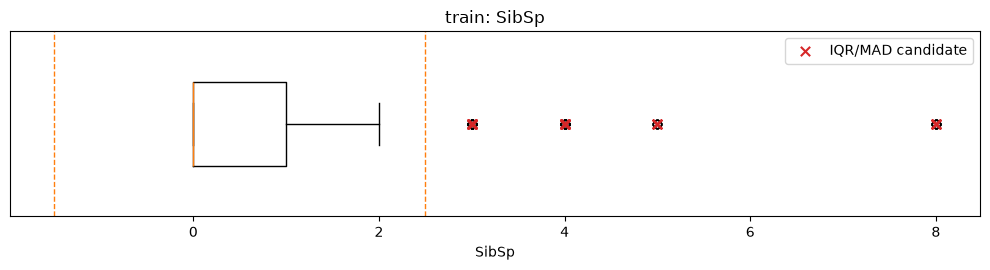

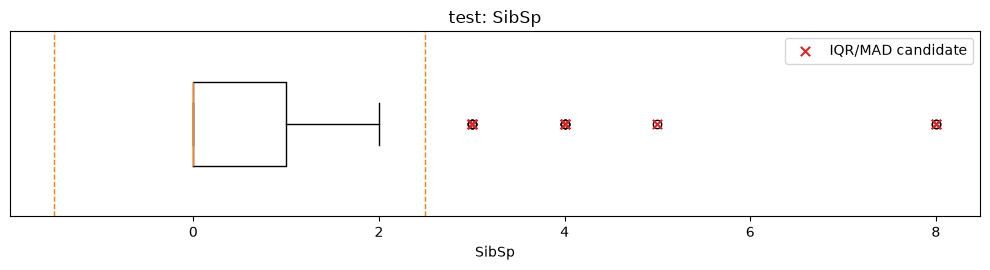

In [4]:
flagged_features = (
    anomaly_report.dataset_summary.loc[
        anomaly_report.dataset_summary["any_outliers"].gt(0),
        "feature",
    ]
    .drop_duplicates()
    .tolist()
)
if not flagged_features:
    print("IQR/MAD-кандидаты не найдены.")
else:
    for feature in flagged_features:
        for dataset_name, frame in eda_datasets.items():
            summary_row = anomaly_report.dataset_summary[
                anomaly_report.dataset_summary["dataset"].eq(dataset_name)
                & anomaly_report.dataset_summary["feature"].eq(feature)
            ].iloc[0]
            if summary_row["any_outliers"] == 0:
                continue
            axis = plot_feature_anomalies(
                frame,
                anomaly_report,
                dataset=dataset_name,
                feature=feature,
            )
            axis.figure.tight_layout()
            plt.show()

## 4. Разобрать конкретные строки

`feature_count` показывает, в скольких признаках строка необычна. Сначала смотрим строки с несколькими флагами, затем самые сильные одиночные отклонения.

In [5]:
display(anomaly_report.flagged_values.head(100).round(4))
display(anomaly_report.row_summary.head(TOP_ROWS).round(4))

context_columns = list(dict.fromkeys(
    [project_config.KEY, project_config.TARGET, *numeric_features]
))
for dataset_name, part in anomaly_report.row_summary.groupby("dataset", sort=False):
    top_rows = part.head(TOP_ROWS)
    source = eda_datasets[dataset_name]
    available_columns = [column for column in context_columns if column in source]
    print(dataset_name.upper())
    display(source.iloc[top_rows["row_position"].astype(int)][available_columns])

,dataset,row_position,row_index,feature,value,iqr_outlier,mad_outlier,iqr_distance,robust_z,severity
0,test,343,343,Fare,512.3292,True,True,19.3461,48.6387,19.3461
1,train,258,258,Fare,512.3292,True,True,19.3461,48.6387,19.3461
2,train,679,679,Fare,512.3292,True,True,19.3461,48.6387,19.3461
3,train,737,737,Fare,512.3292,True,True,19.3461,48.6387,19.3461
4,test,53,53,Fare,263.0000,True,True,8.5478,24.2811,8.5478
...,...,...,...,...,...,...,...,...,...,...
95,train,71,71,SibSp,5.0000,True,False,2.5000,NaN,2.5000
96,train,386,386,SibSp,5.0000,True,False,2.5000,NaN,2.5000
97,train,480,480,SibSp,5.0000,True,False,2.5000,NaN,2.5000
98,train,683,683,SibSp,5.0000,True,False,2.5000,NaN,2.5000


,dataset,row_position,row_index,flagged_features,feature_count,max_severity
0,train,27,27,"Fare, SibSp",2,8.5478
1,train,88,88,"Fare, SibSp",2,8.5478
2,train,341,341,"Fare, SibSp",2,8.5478
3,test,53,53,"Fare, SibSp",2,8.5478
4,test,81,81,"Age, Fare",2,6.7626
5,train,159,159,"Fare, SibSp",2,5.5000
6,train,180,180,"Fare, SibSp",2,5.5000
7,train,201,201,"Fare, SibSp",2,5.5000
8,train,324,324,"Fare, SibSp",2,5.5000
9,train,792,792,"Fare, SibSp",2,5.5000


TRAIN


,PassengerId,Survived,Age,Fare,SibSp,Parch
27,28,0,19.0,263.0000,3,2
88,89,1,23.0,263.0000,3,2
341,342,1,24.0,263.0000,3,2
159,160,0,NaN,69.5500,8,2
180,181,0,NaN,69.5500,8,2
201,202,0,NaN,69.5500,8,2
324,325,0,NaN,69.5500,8,2
792,793,0,NaN,69.5500,8,2
846,847,0,NaN,69.5500,8,2
863,864,0,NaN,69.5500,8,2


TEST


,PassengerId,Age,Fare,SibSp,Parch
53,945,28.0,263.0000,3,2
81,973,67.0,221.7792,1,0
188,1080,NaN,69.5500,8,2
360,1252,14.5,69.5500,8,2
96,988,76.0,78.8500,1,0
343,1235,58.0,512.3292,0,1
69,961,60.0,263.0000,1,4
24,916,48.0,262.3750,1,3
59,951,36.0,262.3750,0,0
64,956,13.0,262.3750,2,2


## 5. Синхронизировать только фактическую сводку

В `docs/02_eda.md` попадут метод и количества. Объяснение и решение остаются ручными.

In [6]:
docs_summary = anomaly_report.dataset_summary[
    [
        "dataset",
        "feature",
        "non_missing",
        "iqr_outliers",
        "mad_outliers",
        "any_outliers",
        "outlier_share",
        "outside_reference_range",
    ]
].copy()
docs_summary["outlier_share"] = docs_summary["outlier_share"].map(
    lambda value: f"{value:.2%}"
)
docs_summary = docs_summary.rename(
    columns={
        "dataset": "Датасет",
        "feature": "Признак",
        "non_missing": "Непустых",
        "iqr_outliers": "IQR",
        "mad_outliers": "MAD",
        "any_outliers": "Любой метод",
        "outlier_share": "Доля",
        "outside_reference_range": "Вне диапазона train",
    }
)
anomaly_block = (
    "Автоматический обзор: [[notebooks/02_eda_anomalies.ipynb|02_eda_anomalies.ipynb]]. "
    f"Границы рассчитаны по `{project_config.TRAIN_DATASET}`: "
    f"IQR × {IQR_MULTIPLIER:g}, robust Z-score через MAD ≥ {ROBUST_Z_THRESHOLD:g}. "
    "Флаги требуют ручной интерпретации и не удаляют строки.\n\n"
    + dataframe_to_markdown(docs_summary)
)
updated = MarkdownDocument(PROJECT_ROOT / "docs/02_eda.md").update_blocks(
    {"eda-anomalies": anomaly_block}
)
print("Обновлены блоки:", ", ".join(updated))

Обновлены блоки: eda-anomalies


## 6. Зафиксировать смысл

Статистический флаг не равен ошибке данных. Просмотрите пассажира в контексте и заполните ручную таблицу раздела «Пропуски, выбросы и аномалии». Если наблюдение ведёт к модельной идее, сохраните его через `02_eda_hypotheses.ipynb` и проверьте отдельным экспериментом.